In [1]:
import pandas as pd
import os

In [4]:
len(pd.read_csv('run_tau1e_6_a1b00005k20_data123454b5b/timings.csv'))#, len(pd.read_csv('run(ortho_diag_all_fxtau_long)/timings.csv'))

42098

In [5]:
len(pd.read_csv('run(ortho_diag_all_fxtau_long)/timings.csv'))

3635

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
def f1(x):
    return 2 * (x/6) + 6.0
def f2(x):
    return 1 * (x**2/9-1/2) - 1.5
def f3(x):
    return (-3) * (np.sin(x)/2) + 0.0

def f4(x):
    spline_degree = 3
    n_internal_knots = 5
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x), np.max(x), n_internal_knots, x)
    B = eval_B['B']
    c = B[:, -1]
    c = c/(np.max(c) - np.min(c))*5.0
    return c

def f5(x):
    spline_degree = 3
    n_internal_knots = 5
    eval_B = eval_spline_basis_equispaced_numeric(spline_degree, np.min(x), np.max(x), n_internal_knots, x)
    B = eval_B['B']
    c = B[:, 0]
    c = c/(np.max(c) - np.min(c))*5.0
    return c

In [51]:
x = np.linspace(-3, 3, 100)

In [52]:
np.std(f1(x)), np.mean(f1(x)), np.std(f2(x)), np.mean(f2(x)), np.std(f3(x)), np.mean(f3(x))

(np.float64(0.5831529302570124),
 np.float64(6.000000000000001),
 np.float64(0.304119842919887),
 np.float64(-1.65993265993266),
 np.float64(1.0798152930248317),
 np.float64(8.326672684688674e-18))

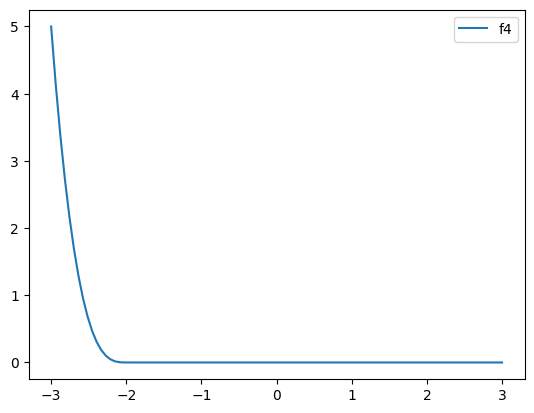

In [58]:
plt.plot(x, f5(x), label='f4')
plt.legend()
plt.show()

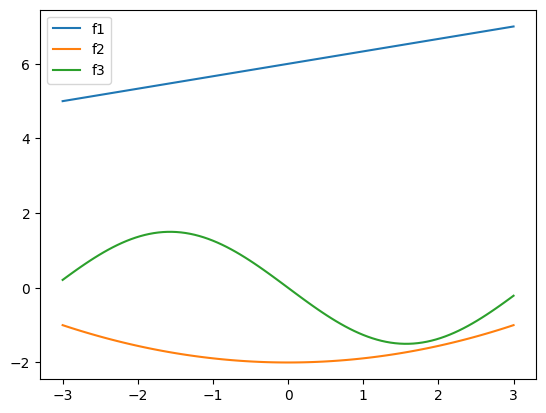

In [53]:
plt.plot(x, f1(x), label='f1')
plt.plot(x, f2(x), label='f2')
plt.plot(x, f3(x), label='f3')
plt.legend()
plt.show()

In [1]:
from _utils_models import *
import pickle
import matplotlib.pyplot as plt

In [2]:
data = pickle.load(open('data.pkl', 'rb'))

In [3]:
data = data[('f1', 0.33)]

In [4]:
x_data, y_data = data[22]
x_order = np.argsort(x_data)

In [5]:
a = 1
b = 0.005
spline_degree = 3
n_internal_knots = 5
penalised=True
order = 2

In [82]:
implementation = 'ortho_centring_T'
K_oc, K_V_oc, K_U_oc, Q_oc, X_oc, X_plot_oc = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [83]:
K_oc.shape, K_V_oc.shape, K_U_oc.shape, X_oc.shape, X_plot_oc.shape

((9, 9), (9,), (9, 9), (100, 9), (500, 9))

In [84]:
implementation = 'svd'
K_svd, K_V_svd, K_U_svd, Q_svd, X_svd, X_plot_svd = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [85]:
K_svd.shape, K_V_svd.shape, K_U_svd.shape, X_svd.shape, X_plot_svd.shape

((8, 8), (8,), (8, 8), (100, 8), (500, 8))

In [86]:
k = K_oc.shape[0]
e_k = np.zeros(k)
e_k[-1] = 1
l = np.argmax(np.abs(K_U_oc.T @ e_k))
print(l)
new_order = np.arange(k)
new_order[l:] = np.arange(l+1, k+1)
new_order[-1] = l
print(new_order)


1
[0 2 3 4 5 6 7 8 1]


In [87]:
K_U_oc = K_U_oc[:, new_order]

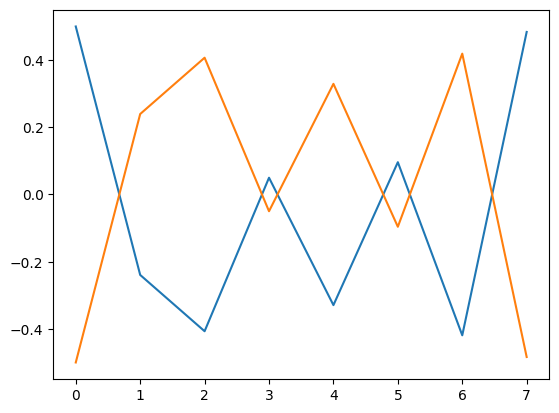

In [102]:
i = 0
plt.plot(K_U_oc[:-1, i])
plt.plot(K_U_svd[:, i])
plt.show()

In [31]:
K_V_oc.sort()
K_V_svd

array([2.73171032e-15, 7.71665843e-02, 5.57231707e-01, 1.93386855e+00,
       4.51280098e+00, 8.10273179e+00, 1.19299673e+01, 1.48862331e+01])

In [ ]:
[]

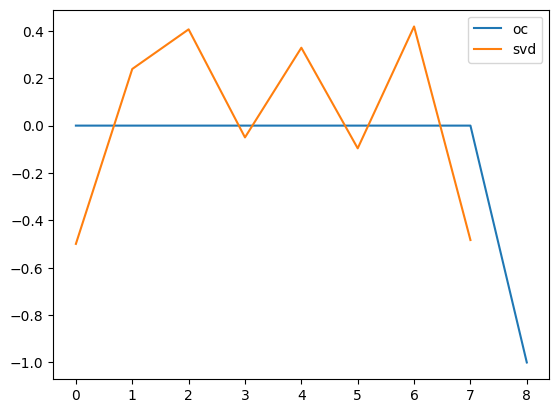

In [67]:
i = 0
plt.plot(K_U_oc[:, i+1], label='oc')
plt.plot(K_U_svd[:, i], label='svd')
plt.legend()
plt.show()

In [60]:
a = 1
b = 0.005
spline_degree = 3
n_internal_knots = 20
penalised=True
order = 2

In [61]:
implementation = 'ortho_centring'
U_oc, S_oc, Vt_oc, X_oc, X_plot_oc = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [62]:
implementation = 'svd'
U_svd, S_svd, Vt_svd, Up_svd, Sp_svd, Vp_svd, X_svd, X_plot_svd = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)

In [63]:
Vt_oc.T[:, -1]

array([0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415, 0.20412415,
       0.20412415, 0.20412415, 0.20412415, 0.20412415])

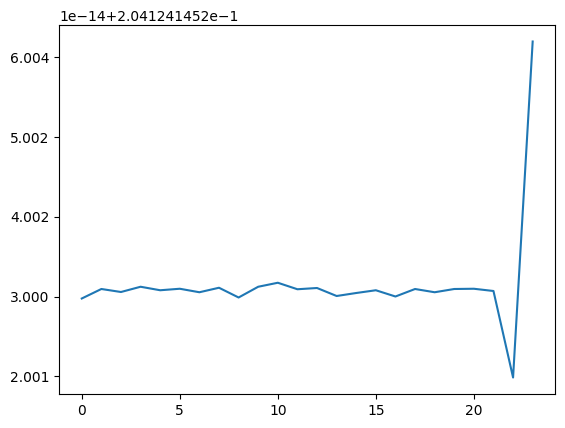

In [64]:
plt.plot(Vt_oc.T[:, -1])

In [65]:
S_svd

array([2.44564793e+00, 2.33717742e+00, 2.21926388e+00, 1.97603849e+00,
       1.82694152e+00, 1.67463028e+00, 1.57893604e+00, 1.55848429e+00,
       1.45436651e+00, 1.38187140e+00, 1.27785229e+00, 1.10090591e+00,
       1.03540801e+00, 9.53429155e-01, 8.36203756e-01, 7.97395152e-01,
       6.62531750e-01, 5.58019057e-01, 5.34289824e-01, 4.42374304e-01,
       3.42726129e-01, 6.95742341e-02, 6.36249240e-02, 3.13017399e-15])

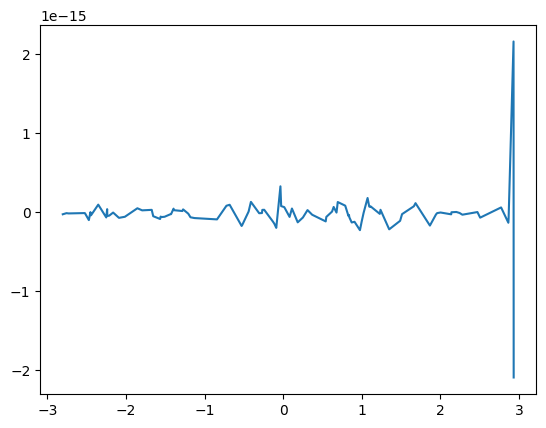

In [66]:
i = -1
plt.plot(x_data[x_order], ((U_oc * S_oc))[x_order, i])
#plt.plot(x_data[x_order], ((Up_svd * Sp_svd))[x_order, i])
plt.show()

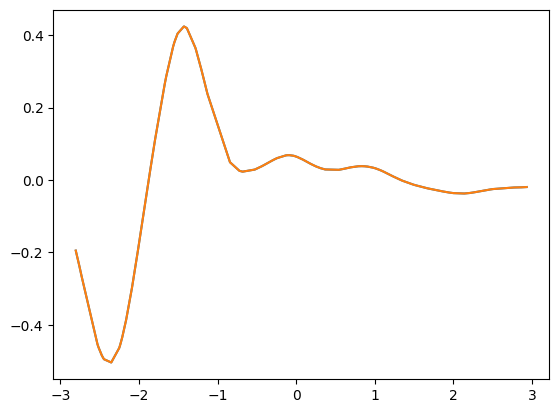

In [67]:
i = 2
plt.plot(x_data[x_order], ((X_oc))[x_order, i])
plt.plot(x_data[x_order], ((X_svd))[x_order, i])
plt.show()

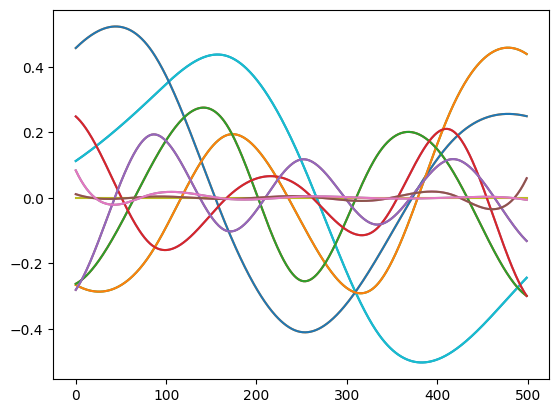

In [46]:
plt.plot(X_plot_oc)
plt.plot(X_plot_svd)
plt.show()

In [48]:
np.sum(X_oc[:, :-1]-X_svd)

np.float64(0.0)

In [30]:
implementation = 'svd'
model, X_svd, X_plot_svd, var_names = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)
    

In [31]:
implementation = 'ortho_centring'
model, X_oc, X_plot_oc, var_names = build_model_ortho_diag(x_data, y_data, a, b, spline_degree, n_internal_knots, implementation, penalised, order)
    

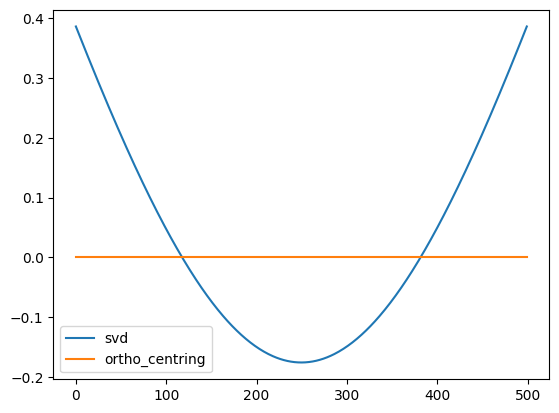

In [46]:
i = 1
plt.plot(X_plot_svd[:, i], label='svd')
plt.plot(X_plot_oc[:, i], label='ortho_centring')
plt.legend()
plt.show()

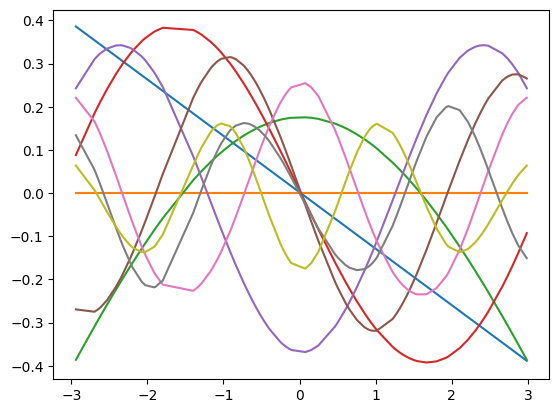

In [29]:
plt.plot(x_data[x_order], X[x_order])
plt.show()